In [1]:
!pip install sinabs


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np

folder_path = r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\saved_data\ROAD"

int_id_data = np.load(folder_path + r"\int_id_data.npy", allow_pickle=True)
attack_labels = np.load(folder_path + r"\attack_labels.npy", allow_pickle=True)


int_id_data_test = np.load(folder_path + r"\int_id_data_test.npy", allow_pickle=True)
attack_labels_test = np.load(folder_path + r"\attack_labels_test.npy", allow_pickle=True)

In [3]:
import builtins
import numpy as np


def sliding_windows_id_data(samples, labels, window_size=32, step=2, attack_labels=('T', 'D', 'F', 'S')):
    n = len(samples)

    if isinstance(attack_labels, str):
        attack_labels = (attack_labels,)

    windows = []
    window_labels = []
    next_id_datas = []
    

    for start in range(0, n - window_size, step):
        end = start + window_size
        window_slice = labels[start:end]

        windows.append(samples[start:end])
        next_id_datas.append(samples[end])

        matching_attack = builtins.next(
            (label for label in attack_labels if label in window_slice),
            'R'
        )
        window_labels.append(matching_attack)

    return (
        np.array(windows, dtype=np.uint8),
        np.array(next_id_datas, dtype=object),
        np.array(window_labels, dtype=object)
    )

In [4]:
windows, windowed_labels = [], []
for i in range(len(int_id_data)):
    windows_batch, next_values, windowed_labels_batch = sliding_windows_id_data(int_id_data[i], attack_labels[i])
    windows.extend(windows_batch)
    windowed_labels.extend(windowed_labels_batch)


In [5]:
windowed_labels = np.array(windowed_labels)
attack_onehot = np.zeros((len(windowed_labels)), dtype=np.uint8)
attack_onehot[windowed_labels == 'T'] = 1

print(attack_onehot[:10])

[0 0 0 0 0 0 0 0 0 0]


In [6]:
windows_test, windowed_labels_test = [], []
for i in range(len(int_id_data)):
    windows_batch, next_values, windowed_labels_batch = sliding_windows_id_data(int_id_data_test[i], attack_labels_test[i])
    windows_test.extend(windows_batch)
    windowed_labels_test.extend(windowed_labels_batch)

In [7]:
windowed_labels_test = np.array(windowed_labels_test)

attack_onehot_test = np.zeros((len(windowed_labels_test)), dtype=np.uint8)
attack_onehot_test[windowed_labels_test == 'T'] = 1

print(attack_onehot_test[:10])

[0 0 0 0 0 0 0 0 0 0]


In [8]:
import torch
from torch.utils.data import Dataset


class CANDataset(Dataset):
    def __init__(
        self,
        windows,
        attack_onehot,
        train=True,
        is_spiking=False,
        time_window=100,
    ):
        # Convert to tensors
        self.windows = torch.as_tensor(windows, dtype=torch.float32)

        # Add channel dimension:
        # (N, H, W) -> (N, 1, H, W)
        if self.windows.ndim == 3:
            self.windows = self.windows.unsqueeze(1)

        self.labels = torch.as_tensor(attack_onehot, dtype=torch.long)

        self.is_spiking = is_spiking
        self.time_window = time_window

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, index):

        img = self.windows[index]
        label = self.labels[index]

        if self.is_spiking:
            # Optional normalization if inputs are not already in [0,1]
            #img = (img - img.min()) / (img.max() - img.min() + 1e-8)

            # Generate spike train
            img = (
                torch.rand(self.time_window, *img.shape) < img
            ).float()

        return img, label

In [9]:
windows = np.array(windows)
print(windows.shape)
print(windows.dtype)
print(windows.min(), windows.max())

print(windows[0])

windows_test = np.array(windows_test)
print(windows_test.shape)
print(windows_test.dtype)
print(windows_test.min(), windows_test.max())

print(windows_test[0])

(2890134, 32, 10)
uint8
0 255
[[  1  83   0   0   0   0   0  12   0  10]
 [  5 225 137  47  96  11  10   1   0 128]
 [  6  98  78 224   0   0  64   0   0   0]
 [  1 156   0 126  32  16   2   0  40 240]
 [  0 208   2 119   4  96  95   3 154   0]
 [  6 158   4  64   4 125  31 192  21  98]
 [  1  37 144   0  65  31  64  63 109  96]
 [  2 193   1 244  15 199 203  31  82 154]
 [  0  51   0   6 120   0  12   2 215 208]
 [  2 116   0 242  32 252 144 124 141 217]
 [  0 192  96   0   0   0   0   0   0   0]
 [  1  98   0   8   4  19 234  17 244 206]
 [  0 167   0  16 249 164 193  46  16 160]
 [  0  14  32  82  86   2   8   9 118 214]
 [  3 193 123  85  31 186 210  83 105  46]
 [  1   7   0   0   0   0   0   0   0   0]
 [ 15 255   0   0   0   0   0   0   0   0]
 [  6 224   3  31   3  27   3  34   3  33]
 [  3  84  32  19  64   0   0   1 136 128]
 [  5 225 137  47  96  11  10   1   0 128]
 [  2 149   0   0   0   0   0   0  24  64]
 [  2 139   0   0   0   0   0   0   0   0]
 [  0 208  10 119   4  9

In [10]:
windows = windows.astype(np.float32) / 255.0
windows_test = windows_test.astype(np.float32) / 255.0

In [11]:
from torch.utils.data import DataLoader

canbus_train = CANDataset(windows, attack_onehot, train=True, is_spiking=False)
train_loader = DataLoader(canbus_train, batch_size=256, shuffle=True)

canbus_test = CANDataset(windows_test, attack_onehot_test, train=False, is_spiking=False)
test_loader = DataLoader(canbus_test, batch_size=256, shuffle=False)

In [12]:
import torch.nn as nn

ann = nn.Sequential(
    # Input: (1, 32, 10)

    nn.Conv2d(
        in_channels=1,
        out_channels=32,
        kernel_size=3,
        stride=1,
        padding=0,
        bias=True
    ),
    nn.ReLU(),

    # Output: (32, 30, 8)

    nn.Conv2d(
        in_channels=32,
        out_channels=64,
        kernel_size=3,
        stride=2,      # Downsampling replaces pooling
        padding=0,
        bias=True
    ),
    nn.ReLU(),

    # Output: (64, 14, 3)

    nn.Flatten(),

    # 64 × 14 × 3 = 2688
    nn.Linear(2688, 64),
    nn.ReLU(),

    nn.Linear(64, 4)
)

In [13]:
from tqdm.auto import tqdm
import torch
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

ann = ann.to(device)
ann.train()

optimizer = torch.optim.Adam(ann.parameters(), lr=1e-3)

n_epochs = 2

for epoch in range(n_epochs):

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")

    for batch_idx, (data, target) in enumerate(progress_bar):

        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        output = ann(data)

        loss = F.cross_entropy(output, target)

        loss.backward()
        optimizer.step()

        # Update loss
        running_loss += loss.item()

        # Predictions
        pred = output.argmax(dim=1)

        # Update accuracy
        correct += (pred == target).sum().item()
        total += target.size(0)

        accuracy = 100 * correct / total

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            avg_loss=f"{running_loss/(batch_idx+1):.4f}",
            acc=f"{accuracy:.2f}%"
        )

    print(
        f"Epoch {epoch+1}/{n_epochs} | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch 1/2:   0%|          | 0/11290 [00:00<?, ?it/s]

Epoch 1/2 | Loss: 0.1168 | Accuracy: 95.26%


Epoch 2/2:   0%|          | 0/11290 [00:00<?, ?it/s]

Epoch 2/2 | Loss: 0.0396 | Accuracy: 98.54%


In [14]:
correct_predictions = []

ann.eval()

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        target = target.to(device)

        output = ann(data)

        pred = output.argmax(dim=1)

        correct_predictions.append(pred == target)

correct_predictions = torch.cat(correct_predictions)

print(f"Accuracy = {100 * correct_predictions.float().mean():.2f}%")

Accuracy = 97.80%


In [15]:
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

ann.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:

        data = data.to(device)
        target = target.to(device)

        output = ann(data)

        pred = output.argmax(dim=1)

        all_preds.append(pred.cpu())
        all_targets.append(target.cpu())

# Concatenate all batches
y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_targets).numpy()

# -------------------------
# Metrics
# -------------------------

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted precision: {precision:.4f}")
print(f"Weighted recall: {recall:.4f}")
print(f"Weighted F1 score: {f1:.4f}")

# -------------------------
# Classification report
# -------------------------

class_names = ["R", "T"]      # Change if using more classes

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=2,
        zero_division=0,
    )
)

# -------------------------
# Confusion matrix
# -------------------------

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)

print("\nConfusion matrix:")
print(cm_df)

# -------------------------
# False Positive Rate
# -------------------------

print("\nFalse positive rate per class:")
for i, cls in enumerate(class_names):
    fp = cm[:, i].sum() - cm[i, i]
    tn = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
    fpr = fp / (fp + tn) if (fp + tn) else 0
    print(f"  {cls}: {fpr:.4f}")

# -------------------------
# False Negative Rate
# -------------------------

print("\nFalse negative rate per class:")
for i, cls in enumerate(class_names):
    fn = cm[i, :].sum() - cm[i, i]
    tp = cm[i, i]
    fnr = fn / (fn + tp) if (fn + tp) else 0
    print(f"  {cls}: {fnr:.4f}")

Accuracy: 0.9780
Weighted precision: 0.9867
Weighted recall: 0.9780
Weighted F1 score: 0.9808

Classification report:
              precision    recall  f1-score   support

           R       1.00      0.98      0.99    703361
           T       0.54      0.95      0.69     18835

    accuracy                           0.98    722196
   macro avg       0.77      0.96      0.84    722196
weighted avg       0.99      0.98      0.98    722196


Confusion matrix:
        R      T
R  688464  14897
T     999  17836

False positive rate per class:
  R: 0.0530
  T: 0.0212

False negative rate per class:
  R: 0.0212
  T: 0.0530


In [16]:
import torch

# Save the trained ANN weights
torch.save(ann.state_dict(), "ann_weights.pth")

In [18]:
from sinabs.from_torch import from_model

input_shape = (1, 32, 10)
num_timesteps = 100  # per sample

sinabs_model = from_model(
    ann, input_shape=input_shape, add_spiking_output=True, synops=False, num_timesteps=num_timesteps
)

In [19]:
sinabs_model.spiking_model

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): IAFSqueeze(spike_threshold=Parameter containing:
  tensor(1.), min_v_mem=Parameter containing:
  tensor(-1.), batch_size=-1, num_timesteps=100)
  (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
  (3): IAFSqueeze(spike_threshold=Parameter containing:
  tensor(1.), min_v_mem=Parameter containing:
  tensor(-1.), batch_size=-1, num_timesteps=100)
  (4): Flatten(start_dim=1, end_dim=-1)
  (5): Linear(in_features=2688, out_features=64, bias=True)
  (6): IAFSqueeze(spike_threshold=Parameter containing:
  tensor(1.), min_v_mem=Parameter containing:
  tensor(-1.), batch_size=-1, num_timesteps=100)
  (7): Linear(in_features=64, out_features=4, bias=True)
  (spike_output): IAFSqueeze(spike_threshold=Parameter containing:
  tensor(1.), min_v_mem=Parameter containing:
  tensor(-1.), batch_size=-1, num_timesteps=100)
)

In [20]:
test_batch_size = 10

spike_mnist_test = CANDataset(
    windows_test, attack_onehot_test, train=False, is_spiking=True, time_window=num_timesteps
)
spike_test_loader = DataLoader(
    spike_mnist_test, batch_size=test_batch_size, shuffle=True
)

In [41]:
import sinabs.layers as sl
import torch
from tqdm import tqdm

correct_predictions = []

for data, target in tqdm(spike_test_loader):
    data, target = data.to(device), target.to(device)


    data = sl.FlattenTime()(data)

    with torch.no_grad():
        output = sinabs_model(data)

        output = output.unflatten(
            0,
            (target.shape[0], output.shape[0] // target.shape[0])
        )

    # Sum spikes over time and predict class
    pred = output.sum(1).argmax(dim=1)

    # Compare predictions with targets
    correct_predictions.append(pred.eq(target))

    # Stop after ~300 samples if desired
    if sum(len(x) for x in correct_predictions) >= 300:
        break

correct_predictions = torch.cat(correct_predictions)

accuracy = correct_predictions.float().mean().item() * 100

print(f"Classification accuracy: {accuracy:.2f}%")

  0%|          | 29/72220 [00:03<2:37:48,  7.62it/s]

Classification accuracy: 96.67%


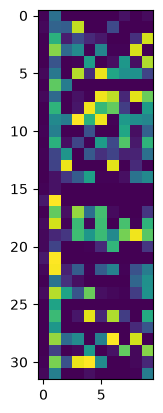

In [22]:
img, label = spike_mnist_test[10]

import matplotlib.pyplot as plt

%matplotlib inline

plt.imshow(img.sum(0)[0]);

In [23]:
import sinabs.layers as sl
import torch
from tqdm import tqdm


stop()

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import numpy as np

sinabs_model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in tqdm(spike_test_loader):

        data = data.to(device)
        target = target.to(device)

        # Flatten time and batch dimensions
        data = sl.FlattenTime()(data)

        output = sinabs_model(data)

        # Restore batch and time dimensions
        output = output.unflatten(
            0,
            (target.shape[0], output.shape[0] // target.shape[0])
        )

        # Sum spikes over time
        pred = output.sum(1).argmax(dim=1)

        all_preds.append(pred.cpu())
        all_targets.append(target.cpu())

# Concatenate all batches
y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_targets).numpy()

# -------------------------
# Metrics
# -------------------------

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Weighted precision: {precision:.4f}")
print(f"Weighted recall: {recall:.4f}")
print(f"Weighted F1 score: {f1:.4f}")

# -------------------------
# Classification report
# -------------------------

class_names = ["R", "T"]       # Change if using 4 classes

print("\nClassification report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=2,
        zero_division=0,
    )
)

# -------------------------
# Confusion matrix
# -------------------------

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names,
)

print("\nConfusion matrix:")
print(cm_df)

# -------------------------
# False Positive / Negative Rates
# -------------------------

print("\nFalse positive rate per class:")
for i, cls in enumerate(class_names):
    fp = cm[:, i].sum() - cm[i, i]
    tn = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
    fpr = fp / (fp + tn) if (fp + tn) else 0
    print(f"  {cls}: {fpr:.4f}")

print("\nFalse negative rate per class:")
for i, cls in enumerate(class_names):
    fn = cm[i, :].sum() - cm[i, i]
    tp = cm[i, i]
    fnr = fn / (fn + tp) if (fn + tp) else 0
    print(f"  {cls}: {fnr:.4f}")

NameError: name 'stop' is not defined

In [24]:
print(type(sinabs_model))
print(sinabs_model)

dummy = torch.rand(100, 1, 32, 10)

with torch.no_grad():
    out = sinabs_model(dummy)

print(out.shape)

<class 'sinabs.network.Network'>
Network(
  (spiking_model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): IAFSqueeze(spike_threshold=Parameter containing:
    tensor(1.), min_v_mem=Parameter containing:
    tensor(-1.), batch_size=-1, num_timesteps=100)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
    (3): IAFSqueeze(spike_threshold=Parameter containing:
    tensor(1.), min_v_mem=Parameter containing:
    tensor(-1.), batch_size=-1, num_timesteps=100)
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=2688, out_features=64, bias=True)
    (6): IAFSqueeze(spike_threshold=Parameter containing:
    tensor(1.), min_v_mem=Parameter containing:
    tensor(-1.), batch_size=-1, num_timesteps=100)
    (7): Linear(in_features=64, out_features=4, bias=True)
    (spike_output): IAFSqueeze(spike_threshold=Parameter containing:
    tensor(1.), min_v_mem=Parameter containing:
    tensor(-1.), batch_size=-1, num_timesteps=100)
  )
  (a

In [34]:
flatten = nir_graph.nodes["spiking_model.4"]

print(type(flatten))
print(flatten.input_type)
print(flatten.output_type)

print(flatten.to_dict())

<class 'nir.ir.flatten.Flatten'>
{'input': None}
{'output': None}
{'start_dim': 0, 'end_dim': -1, 'metadata': {}, 'type': 'Flatten', 'input_type': None}


In [35]:
graph = nir_graph.to_dict()

print(graph["nodes"]["spiking_model.4"])

{'start_dim': 0, 'end_dim': -1, 'metadata': {}, 'type': 'Flatten', 'input_type': None}


In [36]:
import nir
import nirtorch
import sinabs

print(nir.__version__)
print(nirtorch.__version__)
print(sinabs.__version__)

1.0.4
2.0.2
3.1.3


In [43]:
import torch
import nir
from sinabs.nir import to_nir

# Example input matching your network
dummy = torch.rand(100, 1, 32, 10)

# Convert
nir_graph = to_nir(
    sinabs_model,
    dummy
)

import numpy as np

flatten = nir_graph.nodes["spiking_model.4"]

flatten.input_type = {
    "input": np.array([64, 14, 3], dtype=np.int64)
}

flatten.output_type = {
    "output": np.array([2688], dtype=np.int64)
}

print(flatten.input_type)
print(flatten.output_type)

print(flatten.to_dict())


for name, node in nir_graph.nodes.items():
    print(name)

    try:
        d = node.to_dict()

        if "input_type" in d and d["input_type"] is None:
            print("  BAD input_type")

        if "output_type" in d and d["output_type"] is None:
            print("  BAD output_type")

    except Exception as e:
        print(e)

# Save
nir.write("can_ids.nir", nir_graph)

print("Saved can_ids.nir")

{'input': array([64, 14,  3], dtype=int64)}
{'output': array([2688], dtype=int64)}
{'start_dim': 0, 'end_dim': -1, 'metadata': {}, 'type': 'Flatten', 'input_type': array([64, 14,  3], dtype=int64)}
input
spiking_model.0
spiking_model.1
spiking_model.2
spiking_model.3
spiking_model.4
spiking_model.5
spiking_model.6
spiking_model.7
spiking_model.spike_output
output


TypeError: One of data, shape or dtype must be specified

In [ ]:
import sinabs
import nir
import nirtorch

print("Sinabs:", sinabs.__version__)
print("NIR:", nir.__version__)
print("NIRTorch:", nirtorch.__version__)

Sinabs: 3.1.3
NIR: 1.0.4
NIRTorch: 2.0.2


In [44]:
model_path = "can_ids.nir"
nir_model = nir.read(model_path)

KeyError: 'type'